<a href="https://colab.research.google.com/github/QuitoTactico/Courses-and-Certifications/blob/main/notebooks/ml_machinelearninglandscape.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marcoteran/ml/blob/master/notebooks/ml_machinelearninglandscape.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab" title="Abrir y ejecutar en Google Colaboratory"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/marcoteran/ml/blob/master/notebooks/ml_machinelearninglandscape.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Abrir en Kaggle" title="Abrir y ejecutar en Kaggle"/></a>
  </td>
</table>

# Sesión 01: EDA, calidad de datos, preprocesamiento y pipelines
## De auditoría del dataset a experimento confiable

**Aprendizaje de Máquina Aplicado**

**Profesor:** Marco Teran  
**Fecha:** 2026

[Website](http://marcoteran.github.io/),
[Github](https://github.com/marcoteran),
[LinkedIn](https://www.linkedin.com/in/marcoteran/).
___

## Tabla de Contenidos

1. **Introducción y objetivos**
2. **Setup reproducible**
3. **Carga del dataset**
4. **Auditoría del schema**
5. **Calidad de datos y missingness**
6. **EDA univariado y bivariado**
7. **Hallazgos y decisiones para el siguiente bloque**

> **Cómo usar este notebook**  
> Recorre primero la narrativa conceptual, ejecuta después cada celda de código en orden y documenta tus decisiones antes de pasar al siguiente bloque. La meta no es solo que el código corra, sino que cada transformación quede justificada.

---
## Introducción y objetivos

En esta sesión el foco no es “limpiar bonito”, sino **proteger la validez experimental**.
Antes de imputar, codificar o escalar, primero debemos entender:

- qué estructura tiene el dataset,
- qué variable queremos predecir,
- qué problemas de calidad aparecen,
- y qué decisiones deberían esperar hasta después del split.

### Objetivos de aprendizaje

Al finalizar este notebook, deberías ser capaz de:

1. Auditar un dataset tabular con criterio experimental.
2. Detectar faltantes, outliers, tipados dudosos y patrones sospechosos.
3. Identificar variables numéricas y categóricas con mirada de preprocesamiento.
4. Reconocer riesgos tempranos de leakage.
5. Dejar listo el terreno para construir un pipeline reproducible en el siguiente bloque.

### Regla central de la sesión

> Primero auditamos.  
> Luego decidimos.  
> Después transformamos.  
> Y solo entonces automatizamos.

In [1]:
print("¡Bienvenidos al primer notebook!")

¡Bienvenidos al primer notebook!


---

##  Setup reproducible: Configuración del Entorno

### ¿Por qué importan las versiones?

En ML, la reproducibilidad es crucial. Imagina que tu modelo funciona perfectamente en tu computadora pero falla en producción. La causa más común: diferentes versiones de librerías.

**Regla de oro**: Siempre documenta y verifica las versiones de tus dependencias.

### Librerías que usaremos

- **NumPy**: El motor matemático de Python. Maneja arrays y operaciones numéricas eficientemente
- **Pandas**: Como Excel con superpoderes. Organiza datos en DataFrames (tablas)
- **Matplotlib/Seaborn**: Nuestros artistas. Crean visualizaciones profesionales
- **Scikit-learn**: La navaja suiza del ML. Contiene algoritmos, métricas y utilidades

### Configuración visual

Los defaults de matplotlib no son los más bonitos. Vamos a configurar:
- Estilo consistente para todos los gráficos
- Tamaños legibles
- Colores agradables
- Formato de números apropiado

In [2]:
# Configuración inicial del entorno
import sys
import warnings

warnings.filterwarnings('ignore')

# Verificar versión de Python
assert sys.version_info >= (3, 7), "Este notebook requiere Python 3.7 o superior"

print(f"Python {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro} instalado correctamente")

Python 3.12.13 instalado correctamente


It also requires Scikit-Learn ≥ 1.0.1:

In [3]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Iterable, Optional
from scipy import stats

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [4]:
# Verificar versiones de librerías críticas
from packaging import version
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1"), "Requiere scikit-learn >= 1.0.1"
print(f"scikit-learn {sklearn.__version__} instalado")

scikit-learn 1.6.1 instalado


In [5]:
# Configuración visual mínima y estable
SEED = 42
np.random.seed(SEED)

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("husl")

# Configuración de pandas
pd.set_option("display.max_columns", None)
pd.set_option('display.max_rows', 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


print("✅ Entorno configurado y semilla fijada")

✅ Entorno configurado y semilla fijada


### Helpers

Los helpers de este notebook están diseñados para:
- hacer auditoría rápida,
- producir tablas útiles para discusión,
- y mantener el análisis reproducible y legible.

In [6]:
def print_section(title: str, width: int = 88) -> None:
    """Print a visual section delimiter."""
    print("\n" + "=" * width)
    print(title.center(width))
    print("=" * width)


def summarize_schema(df: pd.DataFrame, target: Optional[str] = None) -> pd.DataFrame:
    """Return a compact schema summary."""
    summary = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null": df.notna().sum().values,
        "missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "n_unique": df.nunique(dropna=True).values,
    })
    summary["role"] = "feature"
    if target is not None and target in summary["column"].values:
        summary.loc[summary["column"] == target, "role"] = "target"
    return summary.sort_values(["role", "missing_pct", "column"], ascending=[False, False, True]).reset_index(drop=True)


def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Return a missing-value summary sorted by missingness."""
    out = pd.DataFrame({
        "column": df.columns,
        "missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "dtype": df.dtypes.astype(str).values,
    })
    out = out.sort_values(["missing", "column"], ascending=[False, True]).reset_index(drop=True)
    return out


def detect_duplicate_rows(df: pd.DataFrame) -> pd.DataFrame:
    """Return duplicated rows."""
    dup_mask = df.duplicated(keep=False)
    return df.loc[dup_mask].copy()


def iqr_outlier_rate(series: pd.Series) -> float:
    """Return the percentage of IQR-rule outliers for a numeric series."""
    s = series.dropna()
    if s.empty:
        return 0.0
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    mask = (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)
    return round(mask.mean() * 100, 2)


def numeric_profile(df: pd.DataFrame, columns: Iterable[str]) -> pd.DataFrame:
    """Return a robust numeric profile for selected columns."""
    rows = []
    for col in columns:
        s = df[col].dropna()
        rows.append({
            "column": col,
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
            "min": s.min(),
            "q1": s.quantile(0.25),
            "q3": s.quantile(0.75),
            "max": s.max(),
            "skew": s.skew(),
            "outlier_pct_iqr": iqr_outlier_rate(df[col]),
        })
    return pd.DataFrame(rows).round(3)


def plot_missing_matrix(df: pd.DataFrame, max_rows: int = 250) -> None:
    """Visualize missingness as a compact matrix."""
    sample = df.head(max_rows)
    matrix = sample.isna().astype(int).T.values

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(matrix, aspect="auto", interpolation="nearest")
    ax.set_title("Mapa de missingness (columnas × filas)")
    ax.set_xlabel("Filas (muestra inicial)")
    ax.set_ylabel("Columnas")
    ax.set_yticks(range(len(sample.columns)))
    ax.set_yticklabels(sample.columns)
    ax.set_xticks([])
    plt.tight_layout()
    plt.show()


def plot_missing_bars(df: pd.DataFrame) -> None:
    """Bar plot of missing percentages."""
    miss = missing_summary(df)
    miss = miss[miss["missing"] > 0]
    if miss.empty:
        print("✅ No hay valores faltantes en el dataset de trabajo.")
        return

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(miss["column"], miss["missing_pct"])
    ax.set_title("Porcentaje de valores faltantes por columna")
    ax.set_ylabel("% faltante")
    ax.set_xlabel("Columna")
    ax.axhline(5, linestyle="--", linewidth=1)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


def plot_numeric_audit(df: pd.DataFrame, columns: list[str], target: str) -> None:
    """Plot histogram, boxplot, and target scatter for selected numeric columns."""
    for col in columns:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        # Histograma
        axes[0].hist(df[col].dropna(), bins=40, edgecolor="black", alpha=0.8)
        axes[0].axvline(df[col].mean(), linestyle="--", linewidth=1, label=f"Media: {df[col].mean():.2f}")
        axes[0].axvline(df[col].median(), linestyle=":", linewidth=1, label=f"Mediana: {df[col].median():.2f}")
        axes[0].set_title(f"Distribución: {col}")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Frecuencia")
        axes[0].legend()

        # Boxplot
        axes[1].boxplot(df[col].dropna(), vert=True, patch_artist=True)
        axes[1].set_title(f"Boxplot: {col}")
        axes[1].set_ylabel(col)

        # Relación con target
        valid = df[[col, target]].dropna()
        axes[2].scatter(valid[col], valid[target], alpha=0.2, s=10)
        axes[2].set_title(f"{col} vs {target}")
        axes[2].set_xlabel(col)
        axes[2].set_ylabel(target)

        plt.tight_layout()
        plt.show()


def plot_categorical_audit(df: pd.DataFrame, cat_col: str, target: str) -> None:
    """Audit a categorical feature."""
    counts = df[cat_col].fillna("MISSING").value_counts(dropna=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].bar(counts.index.astype(str), counts.values)
    axes[0].set_title(f"Distribución de categorías: {cat_col}")
    axes[0].set_xlabel(cat_col)
    axes[0].set_ylabel("Frecuencia")
    axes[0].tick_params(axis="x", rotation=45)

    grouped = df[[cat_col, target]].copy()
    grouped[cat_col] = grouped[cat_col].fillna("MISSING")
    category_order = counts.index.astype(str).tolist()

    data_for_box = [
        grouped.loc[grouped[cat_col].astype(str) == level, target].dropna().values
        for level in category_order
    ]
    axes[1].boxplot(data_for_box, labels=category_order, patch_artist=True)
    axes[1].set_title(f"{target} por categoría: {cat_col}")
    axes[1].set_xlabel(cat_col)
    axes[1].set_ylabel(target)
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(df: pd.DataFrame, columns: list[str]) -> None:
    """Simple correlation heatmap using matplotlib only."""
    corr = df[columns].corr(numeric_only=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr.values, aspect="auto", interpolation="nearest", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    ax.set_title("Matriz de correlación")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def quick_interpretation(df: pd.DataFrame, target: str, numeric_cols: list[str]) -> None:
    """Print short interpretation cues after EDA."""
    print_section("LECTURA RÁPIDA DEL EDA")
    print(f"- Filas: {df.shape[0]:,}")
    print(f"- Columnas: {df.shape[1]}")
    print(f"- Target: {target}")
    print(f"- Variables numéricas: {len(numeric_cols)}")
    print(f"- Variables categóricas: {df.select_dtypes(exclude=[np.number]).shape[1]}")
    print(f"- Valores faltantes totales: {int(df.isna().sum().sum())}")
    print(f"- Filas duplicadas exactas: {int(df.duplicated().sum())}")
    print("- Próxima pregunta metodológica: ¿qué transformaciones deben aprenderse solo con train?")

---
## Carga del dataset <a name="datos"></a>

### El dataset de California Housing

**Origen**: Censo de California de 1990
**Tamaño**: 20,640 distritos
**Granularidad**: Cada fila es un distrito, no una casa individual

### ¿Por qué este dataset?

- **Clásico en ML**: Bien estudiado, podemos comparar resultados
- **Tamaño apropiado**: Ni muy pequeño ni muy grande para aprender
- **Problemas reales**: Tiene valores faltantes y peculiaridades
- **Múltiples tipos de datos**: Numéricos y categóricos

### Estrategia de descarga robusta

Implementaremos:
1. **Caché local**: Si ya descargamos, no repetir
2. **Manejo de errores**: Si falla la descarga, informar claramente
3. **Estructura organizada**: Carpeta datasets/ para todos los datos

Queremos utilizar el dataset California Housing, pero también necesitamos:
- al menos una variable categórica,
- algunos faltantes reales para practicar auditoría y preprocesamiento,
- y una base reproducible aunque cambie el entorno.

Por eso este loader hace lo siguiente:

1. intenta cargar el `housing.csv` clásico si existe localmente,
2. intenta ruta típica de Kaggle,
3. si no encuentra nada, usa `fetch_california_housing`,
4. y si hace falta, crea una versión de laboratorio con:
   - columnas renombradas,
   - categorías derivadas,
   - y missingness controlado solo para fines pedagógicos.

In [7]:
def load_classic_housing_csv() -> Optional[pd.DataFrame]:
    """Try common local paths for the classic housing.csv."""
    candidate_paths = [
        Path("datasets/housing/housing.csv"),
        Path("housing.csv"),
        Path("/kaggle/input/california-housing-prices/housing.csv"),
    ]
    for path in candidate_paths:
        if path.exists():
            print(f"📁 Cargando dataset clásico desde: {path}")
            return pd.read_csv(path)
    return None


def build_lab_dataset_from_sklearn(seed: int = 42) -> pd.DataFrame:
    """
    Build a CH2-friendly teaching dataset from sklearn's California Housing.
    Adds categorical features and controlled missingness for pedagogy.
    """
    bunch = fetch_california_housing(as_frame=True)
    df = bunch.frame.copy()

    rename_map = {
        "MedInc": "median_income",
        "HouseAge": "housing_median_age",
        "AveRooms": "avg_rooms",
        "AveBedrms": "avg_bedrooms",
        "Population": "population",
        "AveOccup": "avg_occupancy",
        "Latitude": "latitude",
        "Longitude": "longitude",
        "MedHouseVal": "median_house_value",
    }
    df = df.rename(columns=rename_map)

    # Categóricas derivadas para CH2
    df["income_band"] = pd.cut(
        df["median_income"],
        bins=[-np.inf, 2, 4, 6, np.inf],
        labels=["low", "mid", "upper_mid", "high"],
    )

    df["geo_band"] = pd.cut(
        df["latitude"],
        bins=[-np.inf, 34, 37, np.inf],
        labels=["south", "central", "north"],
    )

    # Missingness controlado solo para práctica
    rng = np.random.default_rng(seed)
    n = len(df)

    income_mask = rng.random(n) < 0.05
    rooms_mask = rng.random(n) < 0.03
    category_mask = rng.random(n) < 0.04

    df.loc[income_mask, "median_income"] = np.nan
    df.loc[rooms_mask, "avg_bedrooms"] = np.nan
    df.loc[category_mask, "income_band"] = np.nan

    # Duplicados controlados muy pequeños para auditoría
    sampled = df.sample(20, random_state=seed)
    df = pd.concat([df, sampled], ignore_index=True)

    return df


def load_ch2_dataset(seed: int = 42) -> tuple[pd.DataFrame, str]:
    """Load the most appropriate dataset for CH2 and return source label."""
    classic = load_classic_housing_csv()
    if classic is not None:
        return classic.copy(), "classic_housing_csv"

    print("📦 No se encontró housing.csv clásico; usando fallback reproducible con sklearn.")
    lab_df = build_lab_dataset_from_sklearn(seed=seed)
    return lab_df, "sklearn_lab_dataset"


housing, data_source = load_ch2_dataset(seed=SEED)
print(f"✅ Fuente de datos: {data_source}")
print(f"✅ Shape del dataset: {housing.shape[0]:,} filas × {housing.shape[1]} columnas")

📦 No se encontró housing.csv clásico; usando fallback reproducible con sklearn.
✅ Fuente de datos: sklearn_lab_dataset
✅ Shape del dataset: 20,660 filas × 11 columnas


---
## Análisis Exploratorio de Datos (EDA)

### ¿Qué es EDA y por qué es crucial?

**EDA es como ser un detective**: Buscas pistas, anomalías y patrones en los datos.

**John Tukey** (inventor del EDA) dijo: "Es mejor una respuesta aproximada a la pregunta correcta que una respuesta exacta a la pregunta incorrecta."

### Primera impresión: Vista rápida

**¿Qué buscamos?**
- Tipos de datos (numéricos, texto, fechas)
- Dimensiones (filas × columnas)
- Valores faltantes obvios
- Rangos sospechosos

**Herramientas**: head(), info(), describe()

### Vista rápida del dataset

En esta sesión queremos responder primero estas preguntas:

- ¿Qué estamos prediciendo?
- ¿Qué tipos de variables tenemos?
- ¿Dónde aparecen faltantes o categorías?
- ¿Existen duplicados?
- ¿Qué distribuciones o relaciones parecen sospechosas?

Antes de transformar, miramos.

In [8]:
TARGET = "median_house_value"

print_section("PRIMERA INSPECCIÓN")
display(housing.head())

print("\nTipos de datos:")
display(housing.dtypes.to_frame(name="dtype").T)

print("\nDescripción numérica rápida:")
display(housing.describe(include=[np.number]).T)


                                   PRIMERA INSPECCIÓN                                   


,median_income,housing_median_age,avg_rooms,avg_bedrooms,population,avg_occupancy,latitude,longitude,median_house_value,income_band,geo_band
0,8.325,41.000,6.984,1.024,322.000,2.556,37.880,-122.230,4.526,high,north
1,8.301,21.000,6.238,0.972,"2,401.000",2.110,37.860,-122.220,3.585,high,north
2,7.257,52.000,8.288,1.073,496.000,2.802,37.850,-122.240,3.521,high,north
3,5.643,52.000,5.817,1.073,558.000,2.548,37.850,-122.250,3.413,upper_mid,north
4,3.846,52.000,6.282,1.081,565.000,2.181,37.850,-122.250,3.422,mid,north



Tipos de datos:


,median_income,housing_median_age,avg_rooms,avg_bedrooms,population,avg_occupancy,latitude,longitude,median_house_value,income_band,geo_band
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,category,category



Descripción numérica rápida:


,count,mean,std,min,25%,50%,75%,max
median_income,"19,631.000",3.872,1.899,0.500,2.566,3.536,4.739,15.000
housing_median_age,"20,660.000",28.640,12.584,1.000,18.000,29.000,37.000,52.000
avg_rooms,"20,660.000",5.429,2.473,0.846,4.441,5.229,6.052,141.909
avg_bedrooms,"20,026.000",1.096,0.472,0.333,1.006,1.049,1.099,34.067
population,"20,660.000","1,425.692","1,132.744",3.000,787.000,"1,166.000","1,725.000","35,682.000"
avg_occupancy,"20,660.000",3.071,10.381,0.692,2.430,2.818,3.282,"1,243.333"
latitude,"20,660.000",35.632,2.136,32.540,33.930,34.260,37.710,41.950
longitude,"20,660.000",-119.570,2.003,-124.350,-121.800,-118.490,-118.010,-114.310
median_house_value,"20,660.000",2.069,1.154,0.150,1.197,1.797,2.647,5.000


---
##  Auditoría del schema

In [9]:
schema_df = summarize_schema(housing, target=TARGET)
print_section("SCHEMA SUMMARY")
display(schema_df)


                                     SCHEMA SUMMARY                                     


,column,dtype,non_null,missing,missing_pct,n_unique,role
0,median_house_value,float64,20660,0,0.000,3842,target
1,median_income,float64,19631,1029,4.980,12451,feature
2,income_band,category,19827,833,4.030,4,feature
3,avg_bedrooms,float64,20026,634,3.070,13878,feature
4,avg_occupancy,float64,20660,0,0.000,18841,feature
5,avg_rooms,float64,20660,0,0.000,19392,feature
6,geo_band,category,20660,0,0.000,3,feature
7,housing_median_age,float64,20660,0,0.000,52,feature
8,latitude,float64,20660,0,0.000,862,feature
9,longitude,float64,20660,0,0.000,844,feature


In [10]:
print_section("SEPARACIÓN BÁSICA ENTRE TARGET Y FEATURES")

feature_cols = [col for col in housing.columns if col != TARGET]
numeric_cols = housing[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = housing[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Target: {TARGET}")
print(f"Número de features: {len(feature_cols)}")
print(f"Features numéricas: {numeric_cols}")
print(f"Features categóricas: {categorical_cols}")


                       SEPARACIÓN BÁSICA ENTRE TARGET Y FEATURES                        
Target: median_house_value
Número de features: 10
Features numéricas: ['median_income', 'housing_median_age', 'avg_rooms', 'avg_bedrooms', 'population', 'avg_occupancy', 'latitude', 'longitude']
Features categóricas: ['income_band', 'geo_band']


### Verificaciones rápidas de integridad

No todo problema de calidad es missingness. También nos importan:
- duplicados,
- columnas con cardinalidad rara,
- y variables con poca variabilidad útil.

In [11]:
print_section("INTEGRIDAD BÁSICA")

duplicated_rows = detect_duplicate_rows(housing)
print(f"Filas duplicadas exactas: {housing.duplicated().sum()}")

low_cardinality_numeric = [
    col for col in numeric_cols
    if housing[col].nunique(dropna=True) <= 10
]
print(f"Variables numéricas con baja cardinalidad: {low_cardinality_numeric}")

high_cardinality_categorical = [
    col for col in categorical_cols
    if housing[col].nunique(dropna=True) > 20
]
print(f"Variables categóricas con cardinalidad alta: {high_cardinality_categorical}")

if not duplicated_rows.empty:
    print("\nEjemplo de duplicados detectados:")
    display(duplicated_rows.head())


                                   INTEGRIDAD BÁSICA                                    
Filas duplicadas exactas: 20
Variables numéricas con baja cardinalidad: []
Variables categóricas con cardinalidad alta: []

Ejemplo de duplicados detectados:


,median_income,housing_median_age,avg_rooms,avg_bedrooms,population,avg_occupancy,latitude,longitude,median_house_value,income_band,geo_band
696,3.906,41.000,4.634,0.901,387.000,2.404,37.690,-122.100,1.784,mid,north
3024,2.531,30.000,5.039,1.193,"1,565.000",2.680,35.140,-119.460,0.458,mid,central
5723,8.113,45.000,6.879,1.012,943.000,2.782,34.180,-118.230,4.466,high,central
6298,3.820,22.000,5.011,1.022,"5,587.000",4.466,34.020,-117.910,1.362,NaN,central
6835,3.000,35.000,3.614,0.989,"1,762.000",2.833,34.080,-118.120,2.539,NaN,central


---
## Calidad de datos y missingness

Una ausencia no es solo una celda vacía.
Importa:

- cuánto falta,
- dónde falta,
- y si el patrón parece arbitrario o sistemático.

In [12]:
miss_df = missing_summary(housing)
print_section("RESUMEN DE VALORES FALTANTES")
display(miss_df)


                              RESUMEN DE VALORES FALTANTES                              


,column,missing,missing_pct,dtype
0,median_income,1029,4.980,float64
1,income_band,833,4.030,category
2,avg_bedrooms,634,3.070,float64
3,avg_occupancy,0,0.000,float64
4,avg_rooms,0,0.000,float64
5,geo_band,0,0.000,category
6,housing_median_age,0,0.000,float64
7,latitude,0,0.000,float64
8,longitude,0,0.000,float64
9,median_house_value,0,0.000,float64


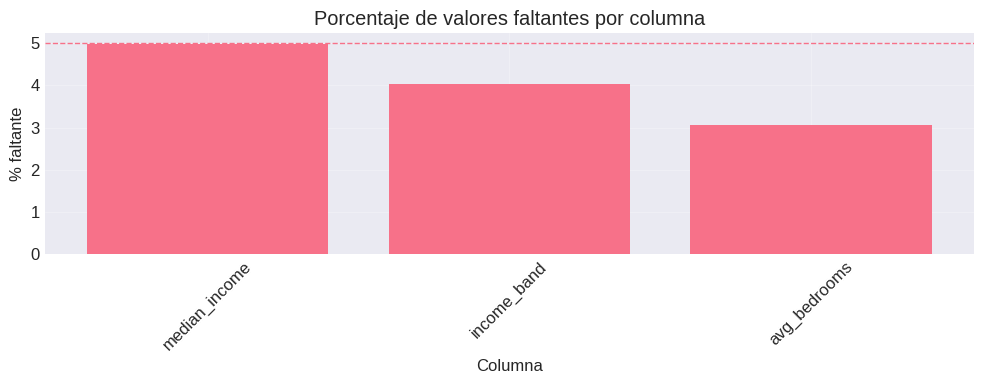

In [13]:
plot_missing_bars(housing)

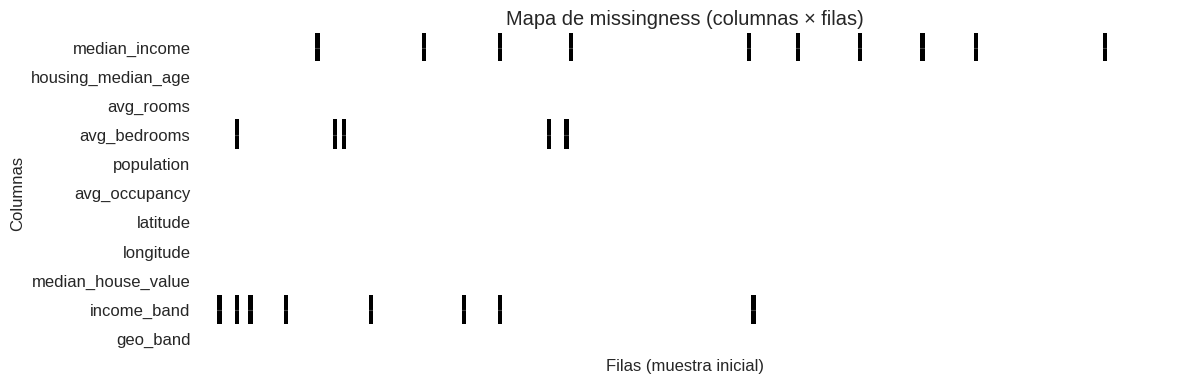

In [14]:
plot_missing_matrix(housing, max_rows=220)

### Lectura guiada

Preguntas para mirar el output anterior:

1. ¿Hay columnas con faltantes leves o ya preocupantes?
2. ¿Los faltantes parecen concentrados en pocas variables?
3. ¿Hay alguna variable categórica con missingness?
4. ¿Qué columnas empezarían a preocupar si luego quisiéramos imputar o codificar?

---
## EDA univariado y bivariado

En CH2 no hacemos EDA por turismo visual.
Hacemos EDA para decidir:

- qué variables requieren transformación,
- cuáles parecen sesgadas,
- dónde podría haber outliers,
- y qué relaciones merecen pasar al siguiente bloque.

In [15]:
selected_numeric_for_audit = [
    col for col in ["median_income", "housing_median_age", "avg_rooms", "avg_bedrooms", "population"]
    if col in housing.columns
]

numeric_profile_df = numeric_profile(housing, selected_numeric_for_audit)
print_section("PERFIL NUMÉRICO ROBUSTO")
display(numeric_profile_df)


                                PERFIL NUMÉRICO ROBUSTO                                 


,column,mean,median,std,min,q1,q3,max,skew,outlier_pct_iqr
0,median_income,3.872,3.536,1.899,0.500,2.566,4.739,15.000,1.648,3.350
1,housing_median_age,28.640,29.000,12.584,1.000,18.000,37.000,52.000,0.060,0.000
2,avg_rooms,5.429,5.229,2.473,0.846,4.441,6.052,141.909,20.704,2.480
3,avg_bedrooms,1.096,1.049,0.472,0.333,1.006,1.099,34.067,32.206,6.910
4,population,"1,425.692","1,166.000","1,132.744",3.000,787.000,"1,725.000","35,682.000",4.931,5.800


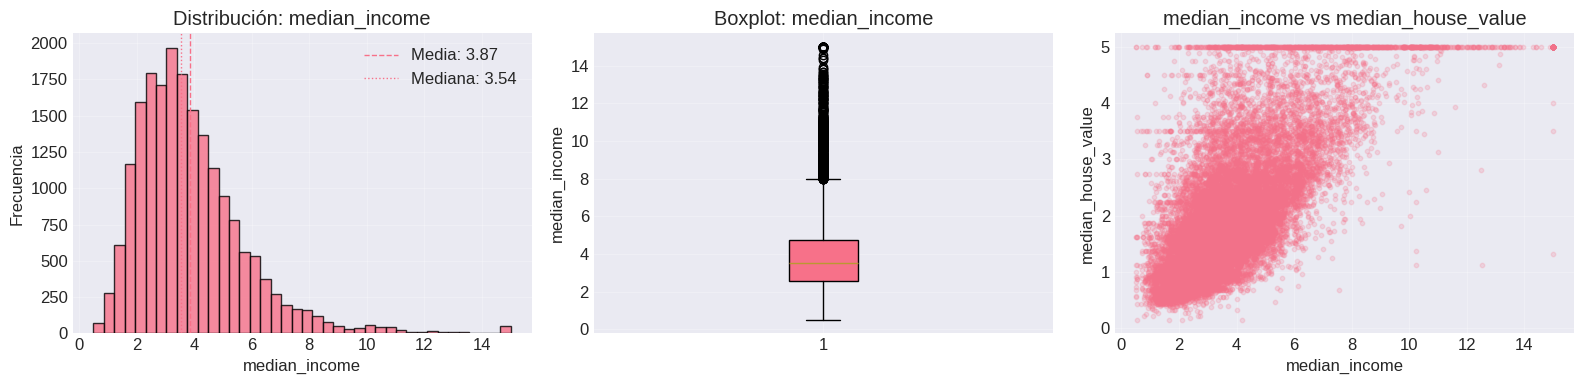

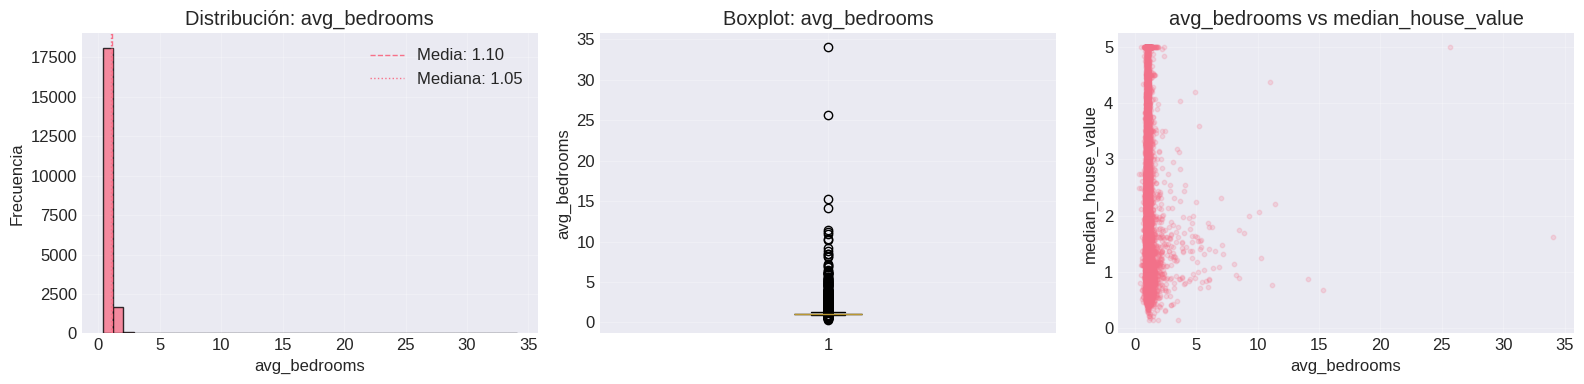

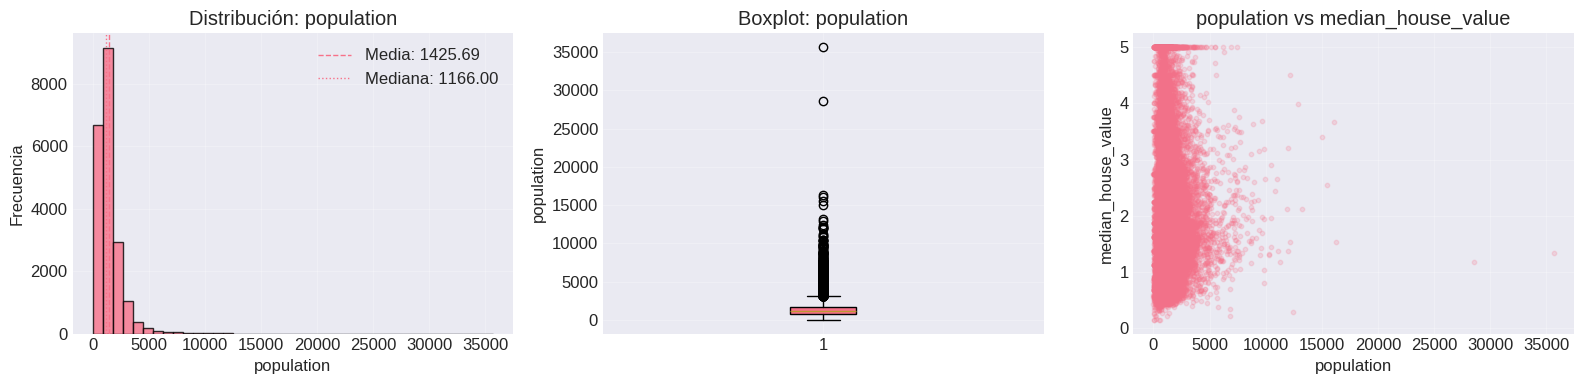

In [16]:
plot_numeric_audit(
    housing,
    columns=[col for col in ["median_income", "avg_bedrooms", "population"] if col in housing.columns],
    target=TARGET,
)

### Lectura guiada de distribuciones

Mientras miras histogramas y boxplots, pregúntate:

- ¿La media y la mediana parecen alejadas?
- ¿Hay colas largas?
- ¿La escala entre variables es comparable?
- ¿Qué variable parece candidata a escalado o transformación?
- ¿Qué outliers parecen error y cuáles podrían ser señal?

In [17]:
if categorical_cols:
    for cat_col in categorical_cols:
        print_section(f"AUDITORÍA CATEGÓRICA: {cat_col}")
        plot_categorical_audit(housing, cat_col=cat_col, target=TARGET)
else:
    print("⚠️ No hay variables categóricas en el dataset actual.")


                           AUDITORÍA CATEGÓRICA: income_band                            


TypeError: Cannot setitem on a Categorical with a new category (MISSING), set the categories first

---
## Relaciones iniciales entre variables

La correlación no resuelve el problema por sí sola, pero sí ayuda a:
- detectar redundancia,
- identificar asociaciones iniciales con el target,
- y descubrir variables que merecen inspección adicional.

In [ ]:
corr_cols = [col for col in numeric_cols + [TARGET] if col in housing.columns]
plot_correlation_heatmap(housing, corr_cols)

In [ ]:
target_corr = (
    housing[corr_cols]
    .corr(numeric_only=True)[TARGET]
    .sort_values(ascending=False)
    .drop(TARGET)
    .to_frame(name="corr_with_target")
)

print_section("CORRELACIÓN CON EL TARGET")
display(target_corr)

### Mini chequeo conceptual

Antes de seguir al próximo chunk:

- Correlación alta no significa causalidad.
- Relación visual fuerte no implica que ya debamos transformar.
- Ver un patrón interesante todavía no autoriza usar todo el dataset para aprender estadísticas.
- El próximo paso será decidir **qué transformaciones tienen sentido** y **cómo hacerlas sin leakage**.

In [ ]:
quick_interpretation(housing, target=TARGET, numeric_cols=numeric_cols)

---
## Hallazgos de este bloque 1

**Checklist de salida**

- [x] Dataset cargado y documentado
- [x] Target identificado
- [x] Schema auditado
- [x] Missingness inspeccionado
- [x] Distribuciones básicas revisadas
- [x] Variables categóricas identificadas
- [x] Relaciones iniciales con el target revisadas

**Preguntas que dejamos listas para el siguiente chunk**

1. ¿Qué columnas imputaríamos y con qué estrategia?
2. ¿Qué variables categóricas requieren encoding?
3. ¿Qué variables parecen sensibles a scaling?
4. ¿Dónde podría aparecer leakage si hacemos preprocessing mal?
5. ¿Cómo encapsulamos todo esto en un `ColumnTransformer` y luego en un `Pipeline`?

---
## Del concepto al código

Este bloque traduce decisiones conceptuales del capítulo a objetos concretos de `scikit-learn`.

**Idea clave**:
- una cosa es detectar un problema en el EDA,
- otra cosa es decidir cómo representarlo en código,
- y otra muy distinta es hacerlo sin leakage.

Este chunk asume que ya ejecutaste el **Chunk 1** y que existen:
- `housing`
- `TARGET`
- `SEED`
- `print_section`

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Split primero, transformaciones después

La regla operativa del capítulo es:

> primero dividimos,  
> luego ajustamos transformaciones solo con train,  
> y después aplicamos esas transformaciones a test.

Aquí comenzamos con una partición simple y reproducible.

In [ ]:
base_feature_cols = [col for col in housing.columns if col != TARGET]

X_full = housing[base_feature_cols].copy()
y_full = housing[TARGET].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    random_state=SEED,
)

print_section("PARTICIÓN DE DATOS")
print(f"Train shape: {X_train_raw.shape}")
print(f"Test shape:  {X_test_raw.shape}")
print(f"Target mean (train): {y_train.mean():,.3f}")
print(f"Target mean (test):  {y_test.mean():,.3f}")

### Análisis Geoespacial

**Mapas geográficos:** Location, location, location

**¿Por qué graficar geográficamente?**
- Precios inmobiliarios son altamente locales
- Revelamos clusters (Silicon Valley, LA, San Diego)
- Detectamos anomalías geográficas

**Técnicas**:
- Scatter plot simple: Ver forma de California
- Color por precio: Zonas caras vs baratas
- Tamaño por población: Densidad urbana


###  Feature engineering determinístico

Este tipo de transformación no aprende estadísticas desde el dataset completo.
Aun así, por disciplina experimental, lo aplicamos **después del split** sobre cada partición.

Aquí solo usamos transformaciones simples y defendibles:
- `bedrooms_per_room`
- `rooms_x_income`
- `occupancy_per_room`

In [ ]:
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add simple deterministic engineered features."""
    out = df.copy()

    if {"avg_bedrooms", "avg_rooms"}.issubset(out.columns):
        out["bedrooms_per_room"] = out["avg_bedrooms"] / out["avg_rooms"]

    if {"avg_rooms", "median_income"}.issubset(out.columns):
        out["rooms_x_income"] = out["avg_rooms"] * out["median_income"]

    if {"avg_occupancy", "avg_rooms"}.issubset(out.columns):
        out["occupancy_per_room"] = out["avg_occupancy"] / out["avg_rooms"]

    out = out.replace([np.inf, -np.inf], np.nan)
    return out


X_train = add_engineered_features(X_train_raw)
X_test = add_engineered_features(X_test_raw)

print_section("FEATURE ENGINEERING BÁSICO")
print(f"Número de columnas antes: {X_train_raw.shape[1]}")
print(f"Número de columnas después: {X_train.shape[1]}")

new_columns = [col for col in X_train.columns if col not in X_train_raw.columns]
print(f"Nuevas variables: {new_columns}")

### Tipado semántico para preprocessing

No toda variable categórica debe tratarse igual.

En este dataset de laboratorio:
- `income_band` puede tratarse como **ordinal**
- `geo_band` puede tratarse como **nominal**

El resto de columnas numéricas seguirán una ruta distinta.

In [ ]:
ordinal_cols = [col for col in ["income_band"] if col in X_train.columns]
categorical_all = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
nominal_cols = [col for col in categorical_all if col not in ordinal_cols]
numeric_cols_chunk2 = X_train.select_dtypes(include=[np.number]).columns.tolist()

print_section("MAPA SEMÁNTICO DE VARIABLES")
print(f"Numéricas ({len(numeric_cols_chunk2)}): {numeric_cols_chunk2}")
print(f"Nominales ({len(nominal_cols)}): {nominal_cols}")
print(f"Ordinales ({len(ordinal_cols)}): {ordinal_cols}")

### Constructor de preprocesadores

Este helper nos permitirá probar distintas decisiones sin reescribir el flujo completo.

Lo que podrá variar:
- estrategia de imputación numérica
- uso o no de scaling
- manejo de categorías nominales y ordinales

In [ ]:
def build_preprocessor(
    numeric_cols: list[str],
    nominal_cols: list[str],
    ordinal_cols: list[str],
    numeric_imputer_strategy: str = "median",
    scale_numeric: bool = True,
) -> ColumnTransformer:
    """Build a safe mixed-type preprocessor."""
    num_steps = [
        ("imputer", SimpleImputer(strategy=numeric_imputer_strategy)),
    ]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))

    numeric_pipe = Pipeline(num_steps)

    transformers = [
        ("num", numeric_pipe, numeric_cols),
    ]

    if nominal_cols:
        nominal_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse=False)),
        ])
        transformers.append(("nom", nominal_pipe, nominal_cols))

    if ordinal_cols:
        ordinal_categories = []
        for col in ordinal_cols:
            if col == "income_band":
                ordinal_categories.append(["low", "mid", "upper_mid", "high"])
            else:
                # Fallback: preserve sorted unique order
                vals = pd.Series(X_train[col].dropna().unique()).astype(str).sort_values().tolist()
                ordinal_categories.append(vals)

        ordinal_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "encoder",
                OrdinalEncoder(
                    categories=ordinal_categories,
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                ),
            ),
        ])
        transformers.append(("ord", ordinal_pipe, ordinal_cols))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
    )
    return preprocessor

### Preview: imputación y encoding como objetos entrenables

Aquí ajustamos el preprocesador **solo con train** y luego inspeccionamos:
- estadísticas aprendidas por la imputación
- shape final de la matriz transformada
- nombres de features resultantes

In [ ]:
preview_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    nominal_cols=nominal_cols,
    ordinal_cols=ordinal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=True,
)

X_train_t = preview_preprocessor.fit_transform(X_train)
X_test_t = preview_preprocessor.transform(X_test)

print_section("PREVIEW DEL PREPROCESSOR")
print(f"Shape train transformado: {X_train_t.shape}")
print(f"Shape test transformado:  {X_test_t.shape}")

feature_names = preview_preprocessor.get_feature_names_out()
preview_df = pd.DataFrame(X_train_t[:5], columns=feature_names)
display(preview_df)

In [ ]:
print_section("ESTADÍSTICAS APRENDIDAS POR IMPUTACIÓN NUMÉRICA")
num_imputer = preview_preprocessor.named_transformers_["num"].named_steps["imputer"]

imputer_learned = pd.DataFrame({
    "column": numeric_cols_chunk2,
    "learned_value": num_imputer.statistics_,
    "strategy": ["median"] * len(numeric_cols_chunk2),
})
display(imputer_learned)

### Preview: scaling como transformación geométrica

Más que memorizar la fórmula, queremos ver el efecto:
- antes del scaling: medias y escalas heterogéneas
- después del scaling: variables comparables en magnitud

In [ ]:
scale_preview_cols = [col for col in ["median_income", "avg_rooms", "population"] if col in X_train.columns]

scale_preview_train = X_train[scale_preview_cols].copy()
scale_preview_test = X_test[scale_preview_cols].copy()

median_fill = scale_preview_train.median()
scale_preview_train = scale_preview_train.fillna(median_fill)
scale_preview_test = scale_preview_test.fillna(median_fill)

scaler = StandardScaler()
scaled_train = scaler.fit_transform(scale_preview_train)
scaled_test = scaler.transform(scale_preview_test)

scale_summary = pd.DataFrame({
    "column": scale_preview_cols,
    "raw_train_mean": scale_preview_train.mean().values,
    "raw_train_std": scale_preview_train.std().values,
    "scaled_train_mean": scaled_train.mean(axis=0),
    "scaled_train_std": scaled_train.std(axis=0),
}).round(3)

print_section("ANTES VS DESPUÉS DEL SCALING")
display(scale_summary)

## Experimentos prácticos

En esta sección no buscamos “el mejor modelo”.
Buscamos ver consecuencias metodológicas de decisiones de preprocessing.

Haremos cuatro experimentos:

1. imputación numérica: `mean` vs `median`
2. sensibilidad a scaling
3. preprocessor mixto y trazabilidad
4. leakage trap con variable sospechosa

In [ ]:
def regression_report(y_true: pd.Series, y_pred: np.ndarray) -> dict:
    """Return a compact regression metrics dictionary."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }


def evaluate_pipeline(
    estimator,
    X_train_data: pd.DataFrame,
    X_test_data: pd.DataFrame,
    y_train_data: pd.Series,
    y_test_data: pd.Series,
    tag: str,
) -> dict:
    """Fit estimator and return metrics."""
    estimator.fit(X_train_data, y_train_data)
    preds = estimator.predict(X_test_data)
    report = regression_report(y_test_data, preds)
    report["experiment"] = tag
    return report

### Experimento 1 — Imputación numérica: `mean` vs `median`

La pregunta no es cuál “gana siempre”.
La pregunta es:

> ¿Cambia algo relevante cuando elegimos una estrategia robusta frente a una sensible a outliers?

In [ ]:
imputation_results = []

for strategy in ["mean", "median"]:
    preprocessor = build_preprocessor(
        numeric_cols=numeric_cols_chunk2,
        nominal_cols=nominal_cols,
        ordinal_cols=ordinal_cols,
        numeric_imputer_strategy=strategy,
        scale_numeric=True,
    )

    model = Pipeline([
        ("preprocess", preprocessor),
        ("regressor", LinearRegression()),
    ])

    result = evaluate_pipeline(
        estimator=model,
        X_train_data=X_train,
        X_test_data=X_test,
        y_train_data=y_train,
        y_test_data=y_test,
        tag=f"LinearRegression + numeric_imputer={strategy}",
    )
    imputation_results.append(result)

imputation_results_df = pd.DataFrame(imputation_results).sort_values("rmse")
print_section("RESULTADOS — IMPUTACIÓN")
display(imputation_results_df)

### Experimento 2 — ¿Cuándo importa el scaling?

Compararemos dos familias:
- **KNN**: sensible a distancias
- **Decision Tree**: normalmente mucho menos sensible a escala

In [ ]:
scaling_results = []

model_specs = [
    ("KNN | no scaling", KNeighborsRegressor(n_neighbors=8), False),
    ("KNN | with scaling", KNeighborsRegressor(n_neighbors=8), True),
    ("Tree | no scaling", DecisionTreeRegressor(max_depth=8, random_state=SEED), False),
    ("Tree | with scaling", DecisionTreeRegressor(max_depth=8, random_state=SEED), True),
]

for tag, regressor, scale_flag in model_specs:
    preprocessor = build_preprocessor(
        numeric_cols=numeric_cols_chunk2,
        nominal_cols=nominal_cols,
        ordinal_cols=ordinal_cols,
        numeric_imputer_strategy="median",
        scale_numeric=scale_flag,
    )

    model = Pipeline([
        ("preprocess", preprocessor),
        ("regressor", regressor),
    ])

    result = evaluate_pipeline(
        estimator=model,
        X_train_data=X_train,
        X_test_data=X_test,
        y_train_data=y_train,
        y_test_data=y_test,
        tag=tag,
    )
    scaling_results.append(result)

scaling_results_df = pd.DataFrame(scaling_results).sort_values("rmse")
print_section("RESULTADOS — SENSIBILIDAD A SCALING")
display(scaling_results_df)

### Experimento 3 — Trazabilidad del preprocessor mixto

Aquí no comparamos métricas.
Verificamos algo más operativo:

- qué entra,
- qué sale,
- y cómo luce la matriz final después de combinar rutas numéricas y categóricas.

In [ ]:
trace_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    nominal_cols=nominal_cols,
    ordinal_cols=ordinal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=True,
)

trace_preprocessor.fit(X_train)

trace_feature_names = trace_preprocessor.get_feature_names_out()
trace_train = trace_preprocessor.transform(X_train[:8])

trace_df = pd.DataFrame(trace_train, columns=trace_feature_names)
print_section("TRAZABILIDAD DEL PREPROCESSOR")
display(trace_df)

### Experimento 4 — Leakage trap

Vamos a construir una variable artificialmente sospechosa:
`target_proxy`

Esto **no** debe hacerse en problemas reales.
La usamos solo para demostrar cómo una variable que “huele” al target puede inflar el resultado.

In [ ]:
rng = np.random.default_rng(SEED)

X_leaky = X_full.copy()
X_leaky["target_proxy"] = y_full + rng.normal(loc=0.0, scale=y_full.std() * 0.03, size=len(y_full))

X_train_leaky_raw, X_test_leaky_raw, y_train_leaky, y_test_leaky = train_test_split(
    X_leaky,
    y_full,
    test_size=0.20,
    random_state=SEED,
)

X_train_leaky = add_engineered_features(X_train_leaky_raw)
X_test_leaky = add_engineered_features(X_test_leaky_raw)

ordinal_cols_leaky = [col for col in ["income_band"] if col in X_train_leaky.columns]
categorical_all_leaky = X_train_leaky.select_dtypes(exclude=[np.number]).columns.tolist()
nominal_cols_leaky = [col for col in categorical_all_leaky if col not in ordinal_cols_leaky]
numeric_cols_leaky = X_train_leaky.select_dtypes(include=[np.number]).columns.tolist()

honest_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    nominal_cols=nominal_cols,
    ordinal_cols=ordinal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=True,
)

leaky_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_leaky,
    nominal_cols=nominal_cols_leaky,
    ordinal_cols=ordinal_cols_leaky,
    numeric_imputer_strategy="median",
    scale_numeric=True,
)

honest_model = Pipeline([
    ("preprocess", honest_preprocessor),
    ("regressor", LinearRegression()),
])

leaky_model = Pipeline([
    ("preprocess", leaky_preprocessor),
    ("regressor", LinearRegression()),
])

leakage_demo_results = []

leakage_demo_results.append(
    evaluate_pipeline(
        estimator=honest_model,
        X_train_data=X_train,
        X_test_data=X_test,
        y_train_data=y_train,
        y_test_data=y_test,
        tag="Honest features only",
    )
)

leakage_demo_results.append(
    evaluate_pipeline(
        estimator=leaky_model,
        X_train_data=X_train_leaky,
        X_test_data=X_test_leaky,
        y_train_data=y_train_leaky,
        y_test_data=y_test_leaky,
        tag="With target_proxy leakage",
    )
)

leakage_demo_df = pd.DataFrame(leakage_demo_results).sort_values("rmse")
print_section("RESULTADOS — LEAKAGE TRAP")
display(leakage_demo_df)

### Lectura metodológica breve del bloque

Antes de pasar al siguiente chunk, interpreta con cuidado:

- Si `median` y `mean` cambian poco, eso no significa que la imputación sea irrelevante.
- Si KNN mejora con scaling y Tree casi no cambia, eso sugiere sensibilidad geométrica distinta.
- Si el preprocessor produce una matriz coherente y trazable, ya vamos en dirección correcta.
- Si aparece una métrica “demasiado buena”, sospecha leakage antes de celebrar.

In [ ]:
print_section("PREGUNTAS QUE DEJA ESTE CHUNK")
questions_chunk2 = [
    "¿Qué estrategia de imputación se ve más defendible aquí y por qué?",
    "¿Qué familia de modelos mostró mayor sensibilidad a scaling?",
    "¿Qué aprendiste al inspeccionar los nombres de features transformadas?",
    "¿Qué señales del experimento de target_proxy indican leakage?",
    "¿Qué parte de este flujo debería quedar encapsulada en un Pipeline final?",
]

for idx, question in enumerate(questions_chunk2, start=1):
    print(f"{idx}. {question}")

## Salida de este bloque 2

**Ya dejamos resuelto:**

- [x] split reproducible
- [x] feature engineering determinístico básico
- [x] mapeo semántico de variables
- [x] preprocessor mixto configurable
- [x] comparación de imputación
- [x] comparación de scaling
- [x] demo de trazabilidad
- [x] leakage trap controlado

**Lo que sigue en el Chunk 3**

- interpretación guiada más fuerte
- práctica activa
- ejercicios de detección de leakage
- mini construcción por parte del estudiante
- tarea final del capítulo

---
## Interpretación

En este chunk cerramos el laboratorio con tres capas:

1. **interpretación guiada** de los experimentos,
2. **práctica activa** para que el estudiante tome decisiones,
3. **tarea final** del capítulo.

La meta ya no es solo ejecutar código, sino justificar criterio metodológico.

In [ ]:
print_section("RESUMEN DE RESULTADOS DISPONIBLES")

available_results = {
    "imputation_results_df": "Comparación de imputación numérica",
    "scaling_results_df": "Sensibilidad a scaling",
    "leakage_demo_df": "Leakage trap con target_proxy",
}

for var_name, description in available_results.items():
    status = "✅ disponible" if var_name in globals() else "⚠️ no encontrado"
    print(f"{status} - {var_name}: {description}")

### Consolidado breve de experimentos

Unificamos los resultados del Chunk 2 en una sola vista compacta para poder leerlos mejor.

In [ ]:
summary_tables = []

if "imputation_results_df" in globals():
    tmp = imputation_results_df.copy()
    tmp["block"] = "imputation"
    summary_tables.append(tmp)

if "scaling_results_df" in globals():
    tmp = scaling_results_df.copy()
    tmp["block"] = "scaling"
    summary_tables.append(tmp)

if "leakage_demo_df" in globals():
    tmp = leakage_demo_df.copy()
    tmp["block"] = "leakage"
    summary_tables.append(tmp)

if summary_tables:
    combined_summary_df = pd.concat(summary_tables, ignore_index=True)
    display(combined_summary_df.sort_values(["block", "rmse", "mae"]))
else:
    combined_summary_df = pd.DataFrame()
    print("⚠️ No hay resultados previos para consolidar. Ejecuta el Chunk 2 primero.")

### Lectura metodológica guiada

No basta con mirar qué fila tiene menor RMSE.  
Queremos aprender a leer el experimento como un científico de datos responsable.

In [ ]:
def interpret_results(
    imputation_df: Optional[pd.DataFrame] = None,
    scaling_df: Optional[pd.DataFrame] = None,
    leakage_df: Optional[pd.DataFrame] = None,
) -> None:
    """Print guided methodological interpretation for the CH2 experiments."""
    print_section("LECTURA METODOLÓGICA GUIADA")

    if imputation_df is not None and not imputation_df.empty:
        best_row = imputation_df.sort_values("rmse").iloc[0]
        worst_row = imputation_df.sort_values("rmse", ascending=False).iloc[0]
        print("1) Imputación")
        print(f"- Mejor configuración observada: {best_row['experiment']}")
        print(f"- RMSE mejor: {best_row['rmse']:.3f}")
        print(f"- RMSE peor:  {worst_row['rmse']:.3f}")
        print("- Pregunta correcta: ¿la diferencia justifica elegir una estrategia más robusta?")
        print()

    if scaling_df is not None and not scaling_df.empty:
        print("2) Scaling")
        scaling_sorted = scaling_df.sort_values("rmse")
        display(scaling_sorted)
        print("- Compare pares del mismo modelo con y sin scaling.")
        print("- Pregunta correcta: ¿el algoritmo depende de distancias o de la geometría del espacio?")
        print()

    if leakage_df is not None and not leakage_df.empty:
        honest = leakage_df[leakage_df["experiment"].str.contains("Honest", case=False, na=False)]
        leaky = leakage_df[leakage_df["experiment"].str.contains("target_proxy|leakage", case=False, na=False)]

        print("3) Leakage")
        if not honest.empty and not leaky.empty:
            honest_row = honest.iloc[0]
            leaky_row = leaky.iloc[0]
            print(f"- Resultado honesto: RMSE={honest_row['rmse']:.3f}, R²={honest_row['r2']:.3f}")
            print(f"- Resultado con leakage: RMSE={leaky_row['rmse']:.3f}, R²={leaky_row['r2']:.3f}")
            print("- Si el salto parece demasiado bueno para ser verdad, primero sospecha fuga de información.")
        else:
            print("- Revisar el experimento de leakage y comparar contra un baseline honesto.")
        print()

    print("Cierre interpretativo:")
    print("- Una métrica mejor no siempre implica una decisión mejor.")
    print("- En CH2, el criterio metodológico importa más que exprimir unas décimas de desempeño.")


interpret_results(
    imputation_df=imputation_results_df if "imputation_results_df" in globals() else None,
    scaling_df=scaling_results_df if "scaling_results_df" in globals() else None,
    leakage_df=leakage_demo_df if "leakage_demo_df" in globals() else None,
)

### Ideas clave del capítulo

Completa mentalmente estas frases antes de seguir:

- Un buen EDA no termina en gráficas; termina en ______________.
- Un preprocesador seguro aprende estadísticas solo con ______________.
- El escalado importa más cuando el modelo depende de ______________.
- Una métrica increíble puede esconder ______________.
- Un pipeline reproducible protege la consistencia entre ______________ y ______________.

---
## Práctica activa

Aquí el foco cambia:

- menos demostración del instructor,
- más decisión del estudiante.

La idea es que puedas justificar acciones de preprocessing y detectar riesgos reales.

### Práctica 1 — Auditoría guiada de variables

Llena la tabla con tu criterio.

**Sugerencia**:
- usa las columnas del schema audit,
- resume tipo, problema detectado y acción sugerida.

In [ ]:
practice1_template = pd.DataFrame({
    "variable": feature_cols[: min(10, len(feature_cols))],
    "tipo": ["" for _ in range(min(10, len(feature_cols)))],
    "problema_detectado": ["" for _ in range(min(10, len(feature_cols)))],
    "accion_sugerida": ["" for _ in range(min(10, len(feature_cols)))],
    "justificacion_corta": ["" for _ in range(min(10, len(feature_cols)))],
})

print_section("PRÁCTICA 1 — PLANTILLA DE AUDITORÍA")
display(practice1_template)

#### Tu tarea

Completa al menos 6 filas con decisiones concretas.

Ejemplos de acciones sugeridas:
- imputar con mediana
- revisar outliers antes de escalar
- codificar con one-hot
- mantener ordinal
- excluir temporalmente
- investigar posible leakage

Puedes editar la plantilla anterior o crear una nueva tabla propia.

### Práctica 2 — Leakage detective

A continuación verás columnas hipotéticas.  
Tu tarea es decidir cuáles son sospechosas de leakage y por qué.

In [ ]:
leakage_cases = pd.DataFrame({
    "column_name": [
        "days_after_sale",
        "risk_score_generated_after_approval",
        "zip_code",
        "future_income_report",
        "last_payment_delay",
        "final_claim_status",
        "city",
        "account_closed_flag",
    ],
    "description": [
        "Número de días transcurridos después de cerrar la venta",
        "Score calculado por un sistema posterior a la aprobación final",
        "Código postal de residencia",
        "Ingreso consolidado reportado meses después del evento objetivo",
        "Retraso en último pago registrado antes del corte",
        "Estado final del reclamo luego de terminar el proceso",
        "Ciudad de residencia declarada al inicio",
        "Indicador de cierre definitivo de cuenta conocido después del outcome",
    ],
    "is_suspicious_leakage": ["", "", "", "", "", "", "", ""],
    "why": ["", "", "", "", "", "", "", ""],
})

print_section("PRÁCTICA 2 — LEAKAGE DETECTIVE")
display(leakage_cases)

#### Preguntas guía

- ¿La columna estaría disponible en el momento real de predicción?
- ¿Fue generada después del outcome?
- ¿Resume una decisión final del proceso?
- ¿Anticipa directamente el target?

Rellena la tabla y luego compara tus respuestas con el instructor o con tus compañeros.

### Práctica 3 — Encoding choice

Decide qué estrategia parece más defendible:

- `one-hot`
- `ordinal`
- `no transformar todavía`

La clave es **semántica primero, encoding después**.

In [ ]:
encoding_cases = pd.DataFrame({
    "variable": [
        "city",
        "education_level",
        "shirt_size",
        "risk_bucket",
        "product_type",
        "severity_band",
        "customer_segment",
    ],
    "possible_values": [
        "Bogotá, Medellín, Cali, Barranquilla",
        "primary, secondary, bachelor, master, PhD",
        "S, M, L, XL",
        "low, medium, high",
        "A, B, C, D",
        "mild, moderate, severe",
        "retail, SME, enterprise",
    ],
    "recommended_encoding": ["", "", "", "", "", "", ""],
    "why": ["", "", "", "", "", "", ""],
})

print_section("PRÁCTICA 3 — ENCODING CHOICE")
display(encoding_cases)

### Práctica 4 — Build your safe preprocessor

Completa el skeleton.  
La idea no es memorizar sintaxis, sino entender la arquitectura correcta:

- numéricas por una ruta,
- categóricas por otra,
- todo dentro de un `ColumnTransformer`.

In [ ]:
# Esqueleto editable para el estudiante
#
# Instrucciones:
# 1. Reemplaza None por listas de columnas adecuadas.
# 2. Completa las estrategias de imputación.
# 3. Decide si usarás scaling en numéricas.
# 4. Ejecuta la celda y revisa si el objeto compila correctamente.

student_numeric_cols = None
student_nominal_cols = None
student_ordinal_cols = None

# student_preprocessor = build_preprocessor(
#     numeric_cols=student_numeric_cols,
#     nominal_cols=student_nominal_cols,
#     ordinal_cols=student_ordinal_cols,
#     numeric_imputer_strategy="median",
#     scale_numeric=True,
# )
#
# student_preprocessor

#### Solución de referencia opcional

Úsala solo después de intentar la práctica por tu cuenta.

In [ ]:
reference_preprocessor = build_preprocessor(
    numeric_cols=numeric_cols_chunk2,
    nominal_cols=nominal_cols,
    ordinal_cols=ordinal_cols,
    numeric_imputer_strategy="median",
    scale_numeric=True,
)

print_section("SOLUCIÓN DE REFERENCIA — PREPROCESSOR")
reference_preprocessor

### Práctica 5 — Mini reflexión escrita

Responde en 3 a 5 líneas:

1. ¿Qué decisión de preprocessing te pareció más sensible en este dataset?
2. ¿Qué error te parece más peligroso: mal encoding, no escalar o leakage?
3. ¿Qué dejarías obligatorio en un pipeline de producción?

---
## Tarea final del capítulo

En esta mini-entrega vas a construir un flujo reproducible y justificar tus decisiones.

**Objetivo**:
pasar de una auditoría del dataset a un pipeline defendible.

### Entregable esperado

Tu entrega debe incluir:

1. **Una justificación corta en markdown** donde expliques:
   - target elegido,
   - variables problemáticas detectadas,
   - estrategia de imputación,
   - decisión de encoding,
   - decisión sobre scaling,
   - riesgo potencial de leakage.

2. **Un bloque de código** con:
   - split correcto,
   - feature engineering básico si aplica,
   - `ColumnTransformer`,
   - `Pipeline`,
   - un baseline sencillo.

3. **Una interpretación corta**:
   - qué aprendiste del flujo,
   - qué decisión fue más importante,
   - y qué revisarías antes de usarlo en un contexto real.

### Plantilla sugerida para la entrega

Copia, completa y mejora esta estructura.

#### Justificación del estudiante

- **Target**:
- **Problemas de calidad detectados**:
- **Imputación elegida**:
- **Encoding elegido**:
- **Scaling**:
- **Posibles riesgos de leakage**:
- **Comentarios adicionales**:

### Código base para la tarea final

In [ ]:
# Instrucciones:
# - Parte de X_full e y_full o de las versiones derivadas del Chunk 2.
# - Puedes reutilizar add_engineered_features y build_preprocessor.
# - Completa el pipeline final y luego evalúalo.

# student_X = X_full.copy()
# student_y = y_full.copy()
#
# student_X_train_raw, student_X_test_raw, student_y_train, student_y_test = train_test_split(
#     student_X,
#     student_y,
#     test_size=0.20,
#     random_state=SEED,
# )
#
# student_X_train = add_engineered_features(student_X_train_raw)
# student_X_test = add_engineered_features(student_X_test_raw)
#
# student_numeric_cols = ...
# student_nominal_cols = ...
# student_ordinal_cols = ...
#
# student_preprocessor = build_preprocessor(
#     numeric_cols=student_numeric_cols,
#     nominal_cols=student_nominal_cols,
#     ordinal_cols=student_ordinal_cols,
#     numeric_imputer_strategy="median",
#     scale_numeric=True,
# )
#
# student_model = Pipeline([
#     ("preprocess", student_preprocessor),
#     ("regressor", LinearRegression()),
# ])
#
# student_model.fit(student_X_train, student_y_train)
# student_preds = student_model.predict(student_X_test)
#
# regression_report(student_y_test, student_preds)

---
## Preguntas de autoevaluación

1. ¿Qué cambio harías primero si tuvieras que robustecer este pipeline para producción?
2. ¿Qué columnas revisarías dos veces por riesgo de leakage?
3. ¿Qué experimento del notebook cambió más tu intuición y por qué?
4. ¿Qué decisión de preprocessing te parece más dependiente del dominio?
5. ¿Qué parte del flujo documentarías con más cuidado para otro miembro del equipo?

## Material Adicional y Referencias

### Referencias Bibliográficas

In [ ]:
references = """
📚 REFERENCIAS Y LECTURAS RECOMENDADAS:

Libros Fundamentales:
• Géron, A. (2019). Hands-On Machine Learning with Scikit-Learn and TensorFlow (2nd ed.)
• Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning
• Kuhn, M., & Johnson, K. (2019). Feature Engineering and Selection

Metodología y Procesos:
• Chapman, P. et al. (2000). CRISP-DM 1.0: Step-by-step data mining guide
• Provost, F., & Fawcett, T. (2013). Data Science for Business

Análisis Exploratorio:
• Tukey, J. W. (1977). Exploratory Data Analysis
• Cleveland, W. S. (1993). Visualizing Data
• Wickham, H., & Grolemund, G. (2017). R for Data Science

Recursos Online:
• Documentación scikit-learn: https://scikit-learn.org/stable/
• Kaggle Learn: https://www.kaggle.com/learn
• Google ML Crash Course: https://developers.google.com/machine-learning/crash-course

Papers Relevantes:
• Breiman, L. (2001). Random Forests. Machine Learning, 45(1), 5-32
• Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System
"""

print(references)

---

**Fin del Notebook**

*Última actualización: 2026*  
*Autor: Adaptado y mejorado para el curso de Machine Learning*